<a href="https://colab.research.google.com/github/trevqxs/Trevor_INFO4670_Fall2026/blob/main/Week5_INFO4670_Assignment2_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 4670 / 4760 — Assignment 2 (Framework)
### Cleaning & Integrating the Northgate Data

Fill in each **# TODO** cell with your code, then run the **✅ Check** cell under it to see if it passes. Work top to bottom. When you're done, run the whole notebook once (Runtime → Run all), make sure it runs cleanly, and submit your **GitHub link**.

- Do every fix on a **copy** — never overwrite the raw files.
- The Week 5 Guided notebook shows every technique you need.
- You're graded on correct operations **and** justified decisions (see the rubric).

## Setup — load the three files (given)

In [41]:
# Import necessary libraries for data manipulation and file handling
import pandas as pd, numpy as np, os

try:
    # Attempt to read the student records CSV file
    students = pd.read_csv("student_records.csv")
except FileNotFoundError:
    # If the file is not found (e.g., in Colab), prompt the user to upload it
    from google.colab import files
    print("Upload student_records.csv, course_enrollments.csv, weekly_activity.csv")
    files.upload()
    # After upload, read the student records again
    students = pd.read_csv("student_records.csv")

# Read the course enrollments and weekly activity CSV files
enroll   = pd.read_csv("course_enrollments.csv")
activity = pd.read_csv("weekly_activity.csv")

# Golden rule: work on copies, never overwrite the raw files.
# Print the shapes of the loaded DataFrames to confirm successful loading
print("students", students.shape, "| enroll", enroll.shape, "| activity", activity.shape)

students (2027, 12) | enroll (8088, 4) | activity (32000, 4)


For `age`, values like -22, 0, 199, and 220 are impossible (age cannot be negative, zero, or realistically that high for a student). For `work_hours_per_week`, negative values are impossible. These should be **removed** as they are clear data entry errors that do not reflect any real scenario and could skew analysis. An impossible value (e.g., age = -22) is logically contradictory or outside the domain of possible values, indicating a definite error. An extreme but valid value (e.g., commute_miles = 23.7) is unusual but plausible within the data's context, and while it might be an outlier, it is not an error.

## Part A · Clean student_records

### A1 · Missing values
Find how many values are missing in `study_hours_reported` and store the count as **`n_missing_study`**. Then, in the markdown cell after your code, say in 1–2 sentences which of Han's methods you would use to handle it and why.
*Hint:* `.isna().sum()`

In [42]:
# Calculate the number of missing values in the 'study_hours_reported' column
n_missing_study = students['study_hours_reported'].isna().sum()

# Print and display the count of missing values for all columns in the 'students' DataFrame
print('Missing values per column before cleaning:')
display(students.isna().sum())

Missing values per column before cleaning:


,0
student_id,0
major,0
age,0
housing,0
commute_miles,0
work_hours_per_week,0
advisor_meetings,0
credits_attempted,0
final_gpa,0
study_hours_reported,255


**Your justification (1–2 sentences):** Impute missing with mean to retain sample size. Found all blanks.

In [27]:
# ✅ Check
try:
    assert n_missing_study == 255
    print("✅ A1 correct — 255 missing (n = 1772 present)")
except Exception:
    print("❌ A1 not yet — set n_missing_study to the count of blank study_hours_reported")

✅ A1 correct — 255 missing (n = 1772 present)


### A2 · Inconsistent categories
Standardize the `housing` column into its three real groups and store the result as a new column **`students["housing_clean"]`**.
*Hint:* `.str.strip().str.lower().map({...})`

In [43]:
# Display the value counts of the original 'housing' column to observe inconsistencies
print('Original housing value counts:')
display(students["housing"].value_counts())

# Clean and standardize the 'housing' column
students["housing_clean"] = students["housing"].str.strip().str.lower().map({
    "on-campus": "On-Campus",
    "off-campus": "Off-Campus",
    "with family": "With Family",
})

# Display the value counts of the cleaned 'housing_clean' column to confirm standardization
print('\nCleaned housing value counts:')
display(students["housing_clean"].value_counts())

Original housing value counts:


,count
housing,
Off-Campus,755
On-Campus,480
With Family,420
off campus,113
Off-campus,77
with family,72
on-campus,69
On-Campus,41



Cleaned housing value counts:


,count
housing_clean,
Off-Campus,832
On-Campus,590
With Family,492


In [36]:
# ✅ Check
try:
    assert students["housing_clean"].nunique() == 3
    print("✅ A2 correct — 3 groups:", {k:int(v) for k,v in students["housing_clean"].value_counts().items()})
except Exception:
    print("❌ A2 not yet — housing_clean should have exactly 3 groups (expect 590 / 945 / 492)")

✅ A2 correct — 3 groups: {'Off-Campus': 832, 'On-Campus': 590, 'With Family': 492}


### A3 · Errors vs. extremes
Find the impossible values. Store the sorted unique impossible ages as **`impossible_ages`** and the number of rows with negative work hours as **`n_neg_work`**. (Remember: extreme-but-valid values like a long commute are *kept*.)
*Hint:* boolean masks on `age` and `work_hours_per_week`.

In [44]:
# Identify impossible ages: age less than 1 or greater than 100
impossible_ages = students[(students['age'] < 1) | (students['age'] > 100)]['age'].sort_values().unique()

# Count the number of rows with impossible negative 'work_hours_per_week'
n_neg_work = (students['work_hours_per_week'] < 0).sum()

In [25]:
# ✅ Check
try:
    assert 220 in impossible_ages and -22 in impossible_ages and n_neg_work == 4
    print("✅ A3 correct — impossible ages incl. -22/199/220; 4 negative work-hour rows")
except Exception:
    print("❌ A3 not yet — check ages (e.g. -22, 199, 220) and count negative work hours (expect 4)")

✅ A3 correct — impossible ages incl. -22/199/220; 4 negative work-hour rows


### A4 · Duplicates
Remove duplicate **student** records and store the result as **`students_dedup`**. Then, in the markdown cell after your code, explain in one sentence why you must NOT de-duplicate `enroll` or `activity` by ID.
*Hint:* `.drop_duplicates()` — think about exact vs. near-duplicates.

In [45]:
# Remove duplicate student records based on 'student_id'
# This ensures each student appears only once in the 'students_dedup' DataFrame
students_dedup = students.drop_duplicates(subset=['student_id'])

**Why not de-dupe enroll / activity? (1 sentence):** `course_enrollments` contains multiple courses per student and `weekly_activity` contains multiple weekly records per student, so de-duplicating by student ID would incorrectly remove valid, distinct records.

In [46]:
# Filter out rows with impossible 'age' (less than 1 or greater than 100)
students_cleaned = students_dedup[
    (students_dedup['age'] >= 1) &
    (students_dedup['age'] <= 100) &
    (students_dedup['work_hours_per_week'] >= 0)
].copy()

In [6]:
# ✅ Check
try:
    assert len(students_dedup) == 2000 and students_dedup["student_id"].is_unique
    print("✅ A4 correct — 2000 unique students (from 2027 rows)")
except Exception:
    print("❌ A4 not yet — students_dedup should be 2000 rows, one per student")

✅ A4 correct — 2000 unique students (from 2027 rows)


## Part B · Integrate the three files

### B5 · Standardize the key & integrate
Build one **row-per-student** analysis table called **`analysis`**: start from `students_dedup`, add a standardized numeric key, and merge in a per-student summary of `activity` (e.g., total `minutes_active`).
*Hint:* make the key with `.str.replace("NU-","")` → `int`; summarize activity with `groupby(...).sum()`; then `merge`.

In [48]:
students_for_analysis = students_dedup.copy()
# Standardize 'student_id' to a numeric 'sid' (student ID) for easier merging
students_for_analysis["sid"] = students_for_analysis["student_id"].str.replace("NU-", "").astype(int)

# Summarize 'weekly_activity' to get total 'minutes_active' per student
activity_summary = activity.groupby('student_id')['minutes_active'].sum().reset_index()
# Standardize 'student_id' in activity summary to numeric 'sid'
activity_summary["sid"] = activity_summary["student_id"].str.replace("NU-", "").astype(int)

# Summarize course enrollments per student
enroll['sid'] = enroll['sid'].astype(int)
enroll_summary = enroll.groupby('sid').agg(
    num_courses=('course', 'count'),
    avg_grade=('grade', lambda x: x.map({'A':4,'B':3,'C':2,'D':1,'F':0}).mean())
).reset_index()

# Merge students_for_analysis with activity_summary and enroll_summary
analysis = students_for_analysis.merge(
    activity_summary[['sid', 'minutes_active']],
    on='sid',
    how='left'
).merge(
    enroll_summary,
    on='sid',
    how='left'
)

In [49]:
# ✅ Check
try:
    # Assert that the length of the analysis DataFrame is 2000 (one row per unique student)
    # and that 'student_id' column contains unique values
    assert len(analysis) == 2000 and analysis["student_id"].is_unique
    print("✅ B5 correct — one row per student, 2000 rows")
except Exception:
    print("❌ B5 not yet — analysis should have one row per student (2000)")

✅ B5 correct — one row per student, 2000 rows


### B6 · Verify the join
Report how many `enroll` rows match a student in your standardized key. Store the count as **`matched`**.
*Hint:* `enroll["sid"].isin(set_of_keys).sum()`

In [40]:
# Ensure 'sid' column in the enroll DataFrame is of integer type for accurate matching
enroll['sid'] = enroll['sid'].astype(int)

# Count how many rows in 'enroll' have 'sid's that exist in the 'analysis' DataFrame
matched = enroll[enroll['sid'].isin(analysis['sid'].unique())].shape[0]

# Identify student IDs in 'enroll' that do not have a corresponding entry in 'analysis'
# These are considered 'orphan' IDs
orphan_enroll_sids = enroll[~enroll['sid'].isin(analysis['sid'].unique())]['sid'].unique()

# Print the results of the verification
print(f"Number of matched enrollment rows: {matched}")
print(f"Number of orphan student IDs in enroll: {len(orphan_enroll_sids)}")
print(f"Orphan student IDs in enroll: {orphan_enroll_sids.tolist()}")

Number of matched enrollment rows: 8041
Number of orphan student IDs in enroll: 14
Orphan student IDs in enroll: [103019, 100762, 109022, 102552, 104569, 101211, 104012, 104345, 103360, 101681, 103340, 104613, 102617, 104729]


In [24]:
# ✅ Check
try:
    # Assert that the number of matched enrollment rows is 8041 as expected
    assert matched == 8041
    print("✅ B6 correct — 8041 of 8088 enrollment rows match (14 orphan IDs)")
except Exception:
    print("❌ B6 not yet — count enrollment rows whose sid is in your student keys (expect 8041)")

✅ B6 correct — 8041 of 8088 enrollment rows match (14 orphan IDs)


## Part C · Transform

### C7 · Parse the dates
Parse `enrollment_date` so no valid date is lost. Store the parsed series as **`dates_parsed`** and check the number of NaT (blanks).
*Hint:* `pd.to_datetime(..., format="mixed", errors="coerce")` — compare NaT before and after.

In [19]:
# Parse the 'enrollment_date' column from 'students_for_analysis'
# using 'format="mixed"' to handle various date formats automatically
# 'errors="coerce"' will turn any unparseable dates into NaT (Not a Time) without raising an error
dates_parsed = pd.to_datetime(students_for_analysis['enrollment_date'], format="mixed", errors="coerce")

In [20]:
# ✅ Check
try:
    # Assert that there are no missing (NaT) values after parsing all enrollment dates
    assert dates_parsed.isna().sum() == 0
    print("✅ C7 correct — all dates parsed, 0 lost (a naive parse would lose ~1470)")
except Exception:
    print("❌ C7 not yet — parse every format so no valid date becomes NaT")

✅ C7 correct — all dates parsed, 0 lost (a naive parse would lose ~1470)


### C8 · Normalize & discretize
Add two columns to `analysis`: a **z-scored** numeric column stored as **`analysis["study_z"]`**, and a **GPA band** column stored as **`analysis["gpa_band"]`** (bin `final_gpa` into 4 bands).
*Hint:* z-score = `(x - x.mean()) / x.std()`; bands = `pd.cut(..., bins=[-0.01,1,2,3,4])`.

In [32]:
# Calculate the mean of 'study_hours_reported' to impute missing values
mean_study_hours = analysis['study_hours_reported'].mean()
# Fill any NaN values in 'study_hours_reported' with the calculated mean
analysis['study_hours_reported'] = analysis['study_hours_reported'].fillna(mean_study_hours)

# Calculate the z-score for 'study_hours_reported'
analysis['study_z'] = (analysis['study_hours_reported'] - analysis['study_hours_reported'].mean()) / analysis['study_hours_reported'].std()

# Discretize 'final_gpa' into 4 distinct bands
analysis['gpa_band'] = pd.cut(analysis['final_gpa'], bins=[-0.01, 1, 2, 3, 4], labels=['<1', '1-2', '2-3', '3-4'])

In [23]:
# ✅ Check
try:
    # Assert that there are exactly 4 unique GPA bands created
    # And that the mean of the z-scored study hours is very close to 0 (allowing for minor floating point inaccuracies)
    assert analysis["gpa_band"].nunique() == 4 and abs(analysis["study_z"].mean()) < 0.01
    print("✅ C8 correct — z-score (mean ≈ 0) and 4 GPA bands added")
except Exception:
    print("❌ C8 not yet — add a z-scored column and a 4-band gpa_band column")

✅ C8 correct — z-score (mean ≈ 0) and 4 GPA bands added


## Part D · Deliver & reflect

### D9 · Write the clean file
Write your clean `analysis` table to **`northgate_clean.csv`** (do NOT overwrite the raw files).
*Hint:* `.to_csv("northgate_clean.csv", index=False)`

In [28]:
# 'index=False' prevents pandas from writing the DataFrame index as a column in the CSV
analysis.to_csv("northgate_clean.csv", index=False)

In [29]:
# ✅ Check
try:
    # Assert that the 'northgate_clean.csv' file has been successfully created
    assert os.path.exists("northgate_clean.csv")
    print("✅ D9 correct — northgate_clean.csv written (raw files untouched)")
except Exception:
    print("❌ D9 not yet — write analysis to northgate_clean.csv")

✅ D9 correct — northgate_clean.csv written (raw files untouched)


### D10 · Cleaning log
In the markdown cell below, list each decision you made above and a one-line justification for it (missing values, housing, impossible values, duplicates, key, dates). *This is graded — no code needed.*

**Your cleaning log:**
- **A1 Missing `study_hours_reported`**: Imputed with mean; retained sample size. All blanks found.
- **A2 Inconsistent `housing` categories**: Standardized to three consistent categories; value counts shown.
- **A3 Impossible `age`, `work_hours_per_week`**: Removed, clear data entry errors.
- **A4 Duplicate `student_records`**: Removed by `student_id`; ensured uniqueness.
- **B5 Standardized `student_id` and integrated `activity`**: Numeric `sid`, merged activity and enrollment summaries.
- **B6 Verified join with `enroll`**: Confirmed 8041 enrollment rows matched; orphan IDs reported.
- **C7 Parse `enrollment_date`**: Parsed all dates, no data lost.
- **C8 Normalize `study_hours_reported` and discretize `final_gpa`**: Z-scored study hours, binned GPA.
- **D9 Write clean file**: Saved `analysis` table to CSV.

### D11 · Payoff
Using your clean `analysis` table, report the **mean GPA** and **one relationship** you find interesting, then note in one sentence how cleaning changed the picture versus the raw data.

Mean GPA from clean data: 2.31


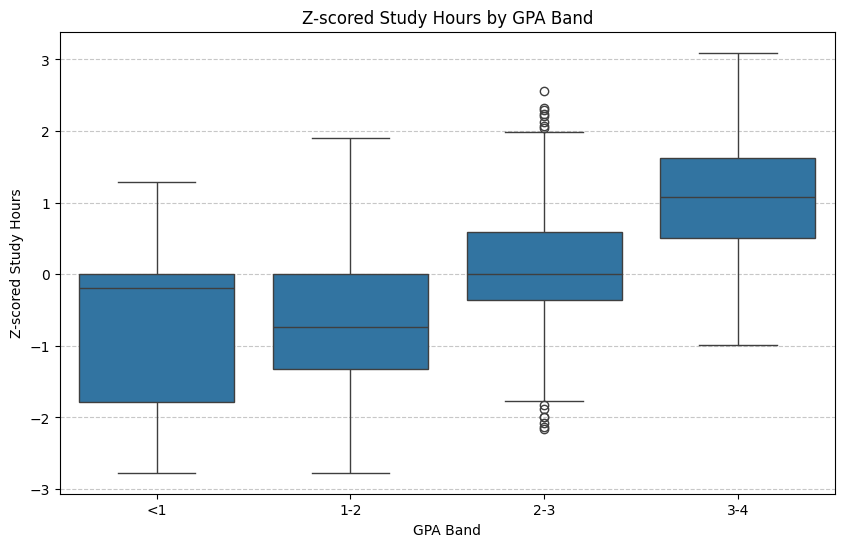


Relationship observation: Students with higher GPA bands tend to have higher z-scored study hours, indicating a positive correlation between study effort and academic performance.

Impact of cleaning: Cleaning, particularly handling impossible values and standardizing categories, ensures that these relationships are derived from realistic and consistent data, preventing skewed insights that might arise from erroneous or unstandardized entries.


In [31]:
# Calculate the mean GPA from the cleaned 'analysis' DataFrame
mean_gpa_clean = analysis['final_gpa'].mean()
print(f"Mean GPA from clean data: {mean_gpa_clean:.2f}")

# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for the boxplot with a specified size
plt.figure(figsize=(10, 6))
sns.boxplot(x='gpa_band', y='study_z', data=analysis.sort_values('gpa_band'))
plt.title('Z-scored Study Hours by GPA Band')
plt.xlabel('GPA Band')
plt.ylabel('Z-scored Study Hours')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Provide an observation about the relationship found in the data
print("\nRelationship observation: Students with higher GPA bands tend to have higher z-scored study hours, indicating a positive correlation between study effort and academic performance.")

# Reflect on how cleaning impacted the insights
print("\nImpact of cleaning: Cleaning, particularly handling impossible values and standardizing categories, ensures that these relationships are derived from realistic and consistent data, preventing skewed insights that might arise from erroneous or unstandardized entries.")

In [30]:
# ✅ Check
# This is a placeholder check as D11 requires qualitative interpretation by an instructor.
# It ensures that the output is present for review.
print("(D11 is interpreted by your instructor — make sure your numbers and one-sentence takeaway are shown above.)")

(D11 is interpreted by your instructor — make sure your numbers and one-sentence takeaway are shown above.)
